Leaf Classification

The purpose of this task is to classify leaf images using supervised machine learning. This process includes preparing the data, analyzing the data and reviewing the analysis.

The dataset consists of three leaf classes: Basil, Lemon and Chinar. The original images contain RGB values which need to be converted to grayscale for the purpose of the analysis. The images are sourced from Kaggle.

To train the classifiers the following methods are used: Ridge Classifier, Random Forest and Multi-Layer Perceptron.

In [312]:
#All imports are done here
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import skimage as ski

#For data-analysis methods
import sklearn as sk
import sklearn.preprocessing as skp
import sklearn.linear_model as sklm
from sklearn.model_selection import GridSearchCV, cross_val_score, StratifiedKFold, train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.neural_network import MLPClassifier
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay, classification_report


#For future proof image handling instead of skimage.io
import imageio.v3 as iio

#For reading files from folders
from pathlib import Path

#Computer vision
import cv2 as cv

#For data visualization
import seaborn as sns

In [195]:
#Importing all images
basil = []
for file in Path('Basil').iterdir():
  if not file.is_file():
    continue

  basil.append(iio.imread(file))

chinar = []
for file in Path('Chinar').iterdir():
  if not file.is_file():
    continue

  chinar.append(iio.imread(file))

lemon = []
for file in Path('Lemon').iterdir():
  if not file.is_file():
    continue

  lemon.append(iio.imread(file))

In [196]:
#Converting all images to 3-bit grayscale
categories = [basil, chinar, lemon]
all_gray = []
all_red = []
all_green = []
all_blue = []

for leaves in categories:
  for leaf in leaves:
    grayLeaf = ski.color.rgb2gray(leaf)
    grayLeaf = np.uint8(np.clip(grayLeaf * 8, 0, 7))
    all_gray.append(grayLeaf)
    all_blue.append(leaf[:,:,0])
    all_green.append(leaf[:,:,1])
    all_red.append(leaf[:,:,2])

In [197]:
#Combining all images into one list and listing all the labels

#Images: 184, 120, 180
X = np.stack(all_gray)
X_width = X[:, ]

#Labels 0: basil, 1: chinar, 2: lemon
Y = np.concatenate([
    np.zeros(len(basil), dtype=int),
    np.ones(len(chinar), dtype=int),
    np.full(len(lemon), 2, dtype=int)
])

In [198]:
#Mean values for each image and each RGB channel
#Result is the average value for a single image and a single color

all_red = np.array(all_red)
red_mean = np.mean(all_red, axis=(1,2))

all_green = np.array(all_green)
green_mean = np.mean(all_green, axis=(1,2))


all_blue = np.array(all_blue)
blue_mean = np.mean(all_blue, axis=(1,2))


In [199]:
#Variance values for each image and each RGB channel
#Result is the average value for a single image and a single color

red_var = np.var(all_red, axis=(1,2))
green_var = np.var(all_green, axis=(1,2))
blue_var = np.var(all_blue, axis=(1,2))

In [200]:
#Gray-Level Co-Occurrence Matrix (GLCM)
#Correlation for GLCM means how similar each pixel is to it's neighbours.
#High correlation means there is less "texture" in the image so the whole image is more homogenous.

glcm_vertical_1 = []
glcm_vertical_2 = []
glcm_horizontal_1 = []
glcm_horizontal_2 = []

for leaf in X:
  glcm = ski.feature.graycomatrix(
    leaf, distances=[1], angles=[0], levels=8, symmetric=False, normed=True 
  )
  glcm_horizontal_1.append(ski.feature.graycoprops(glcm, 'correlation')[0, 0])

glcm_horizontal_1 = np.array(glcm_horizontal_1)

for leaf in X:
  glcm = ski.feature.graycomatrix(
    leaf, distances=[2], angles=[0], levels=8, symmetric=False, normed=True 
  )
  glcm_horizontal_2.append(ski.feature.graycoprops(glcm, 'correlation')[0, 0])

glcm_horizontal_2 = np.array(glcm_horizontal_2)

for leaf in X:
  glcm = ski.feature.graycomatrix(
    leaf, distances=[1], angles=[np.pi/2], levels=8, symmetric=False, normed=True 
  )
  glcm_vertical_1.append(ski.feature.graycoprops(glcm, 'correlation')[0, 0])

glcm_vertical_1 = np.array(glcm_vertical_1)

for leaf in X:
  glcm = ski.feature.graycomatrix(
    leaf, distances=[2], angles=[np.pi/2], levels=8, symmetric=False, normed=True 
  )
  glcm_vertical_2.append(ski.feature.graycoprops(glcm, 'correlation')[0, 0])

glcm_vertical_2 = np.array(glcm_vertical_2)

In [201]:
feature_vector = pd.concat([
  pd.DataFrame(Y),
  pd.DataFrame(red_mean),
  pd.DataFrame(red_var),
  pd.DataFrame(green_mean),
  pd.DataFrame(green_var),
  pd.DataFrame(blue_mean),
  pd.DataFrame(blue_var),
  pd.DataFrame(glcm_vertical_1),
  pd.DataFrame(glcm_vertical_2),
  pd.DataFrame(glcm_horizontal_1),
  pd.DataFrame(glcm_horizontal_2),
], axis=1)

feature_vector = feature_vector.set_axis([
  'leaf',
  'red_mean',
  'red_var',
  'green_mean', 
  'green_var', 
  'blue_mean', 
  'blue_var', 
  'glcm_vertical_1', 
  'glcm_vertical_2', 
  'glcm_horizontal_1', 
  'glcm_horizontal_2'
  ], axis=1)

In [202]:
feature_vector['glcm_mean'] = feature_vector[[
  'glcm_vertical_1', 
  'glcm_vertical_2', 
  'glcm_horizontal_1', 
  'glcm_horizontal_2'
  ]].mean(axis=1)

idx = (feature_vector.groupby('leaf')['glcm_mean'].transform(max) == feature_vector['glcm_mean'])
template_leaves = feature_vector[idx]

In [203]:
#Additional image-based features
basil_scores = []
chinar_scores = []
lemon_scores = []

basil_template = all_gray[template_leaves['leaf'].index[0]]
chinar_template = all_gray[template_leaves['leaf'].index[1]]
lemon_template = all_gray[template_leaves['leaf'].index[2]]

for leaf in all_gray:
  res = cv.matchTemplate(leaf, basil_template, cv.TM_CCOEFF_NORMED)
  basil_scores.append(res.max())

for leaf in all_gray:
  res = cv.matchTemplate(leaf, chinar_template, cv.TM_CCOEFF_NORMED)
  chinar_scores.append(res.max())

for leaf in all_gray:
  res = cv.matchTemplate(leaf, lemon_template, cv.TM_CCOEFF_NORMED)
  lemon_scores.append(res.max())

template_matching_scores = pd.DataFrame([basil_scores, chinar_scores, lemon_scores])

template_matching_scores = template_matching_scores.T
template_matching_scores.columns = ['basil_match', 'chinar_match', 'lemon_match']

feature_vector = pd.concat([feature_vector, template_matching_scores], axis=1)

In [204]:
y = feature_vector['leaf']
y.columns = ['leaf']
feature_vector_complete = feature_vector.drop(['leaf','glcm_mean'], axis=1)

scaler = skp.StandardScaler()
X = pd.DataFrame(scaler.fit_transform(feature_vector_complete))
X.columns = feature_vector_complete.columns

feature_vector_scaled = pd.concat([y,X], axis=1)

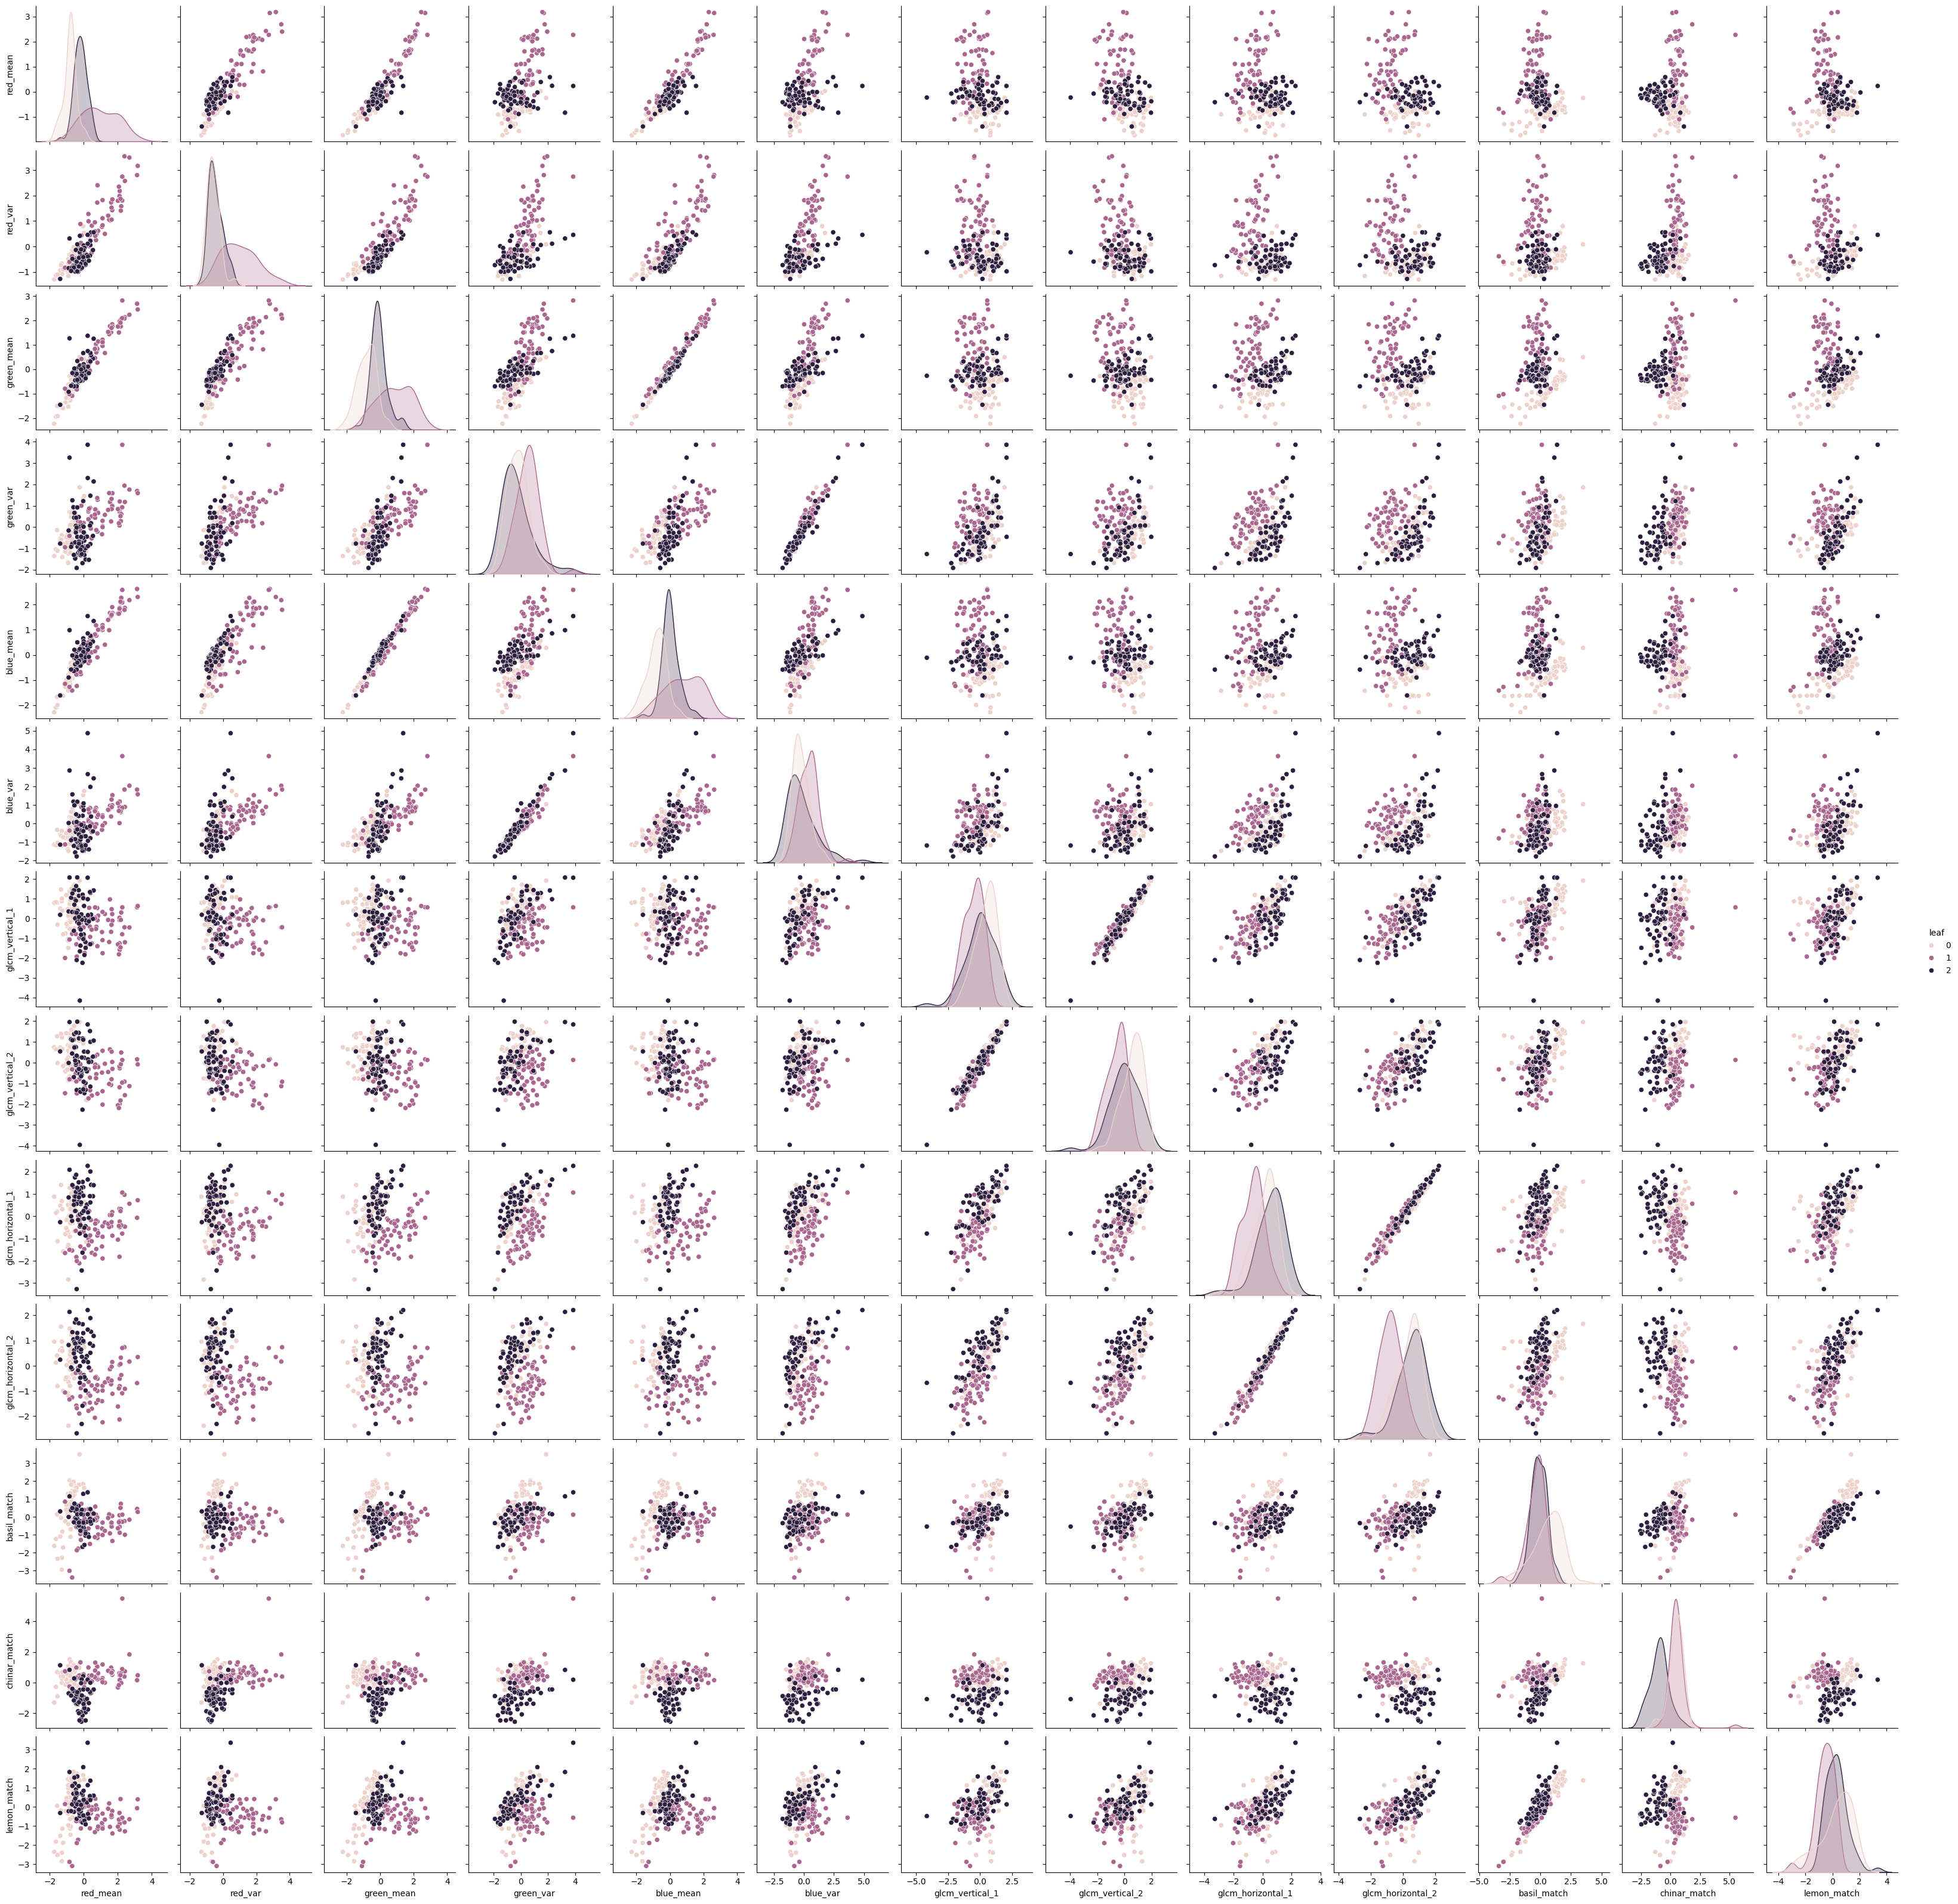

In [205]:
sns.pairplot(feature_vector_scaled, hue='leaf')

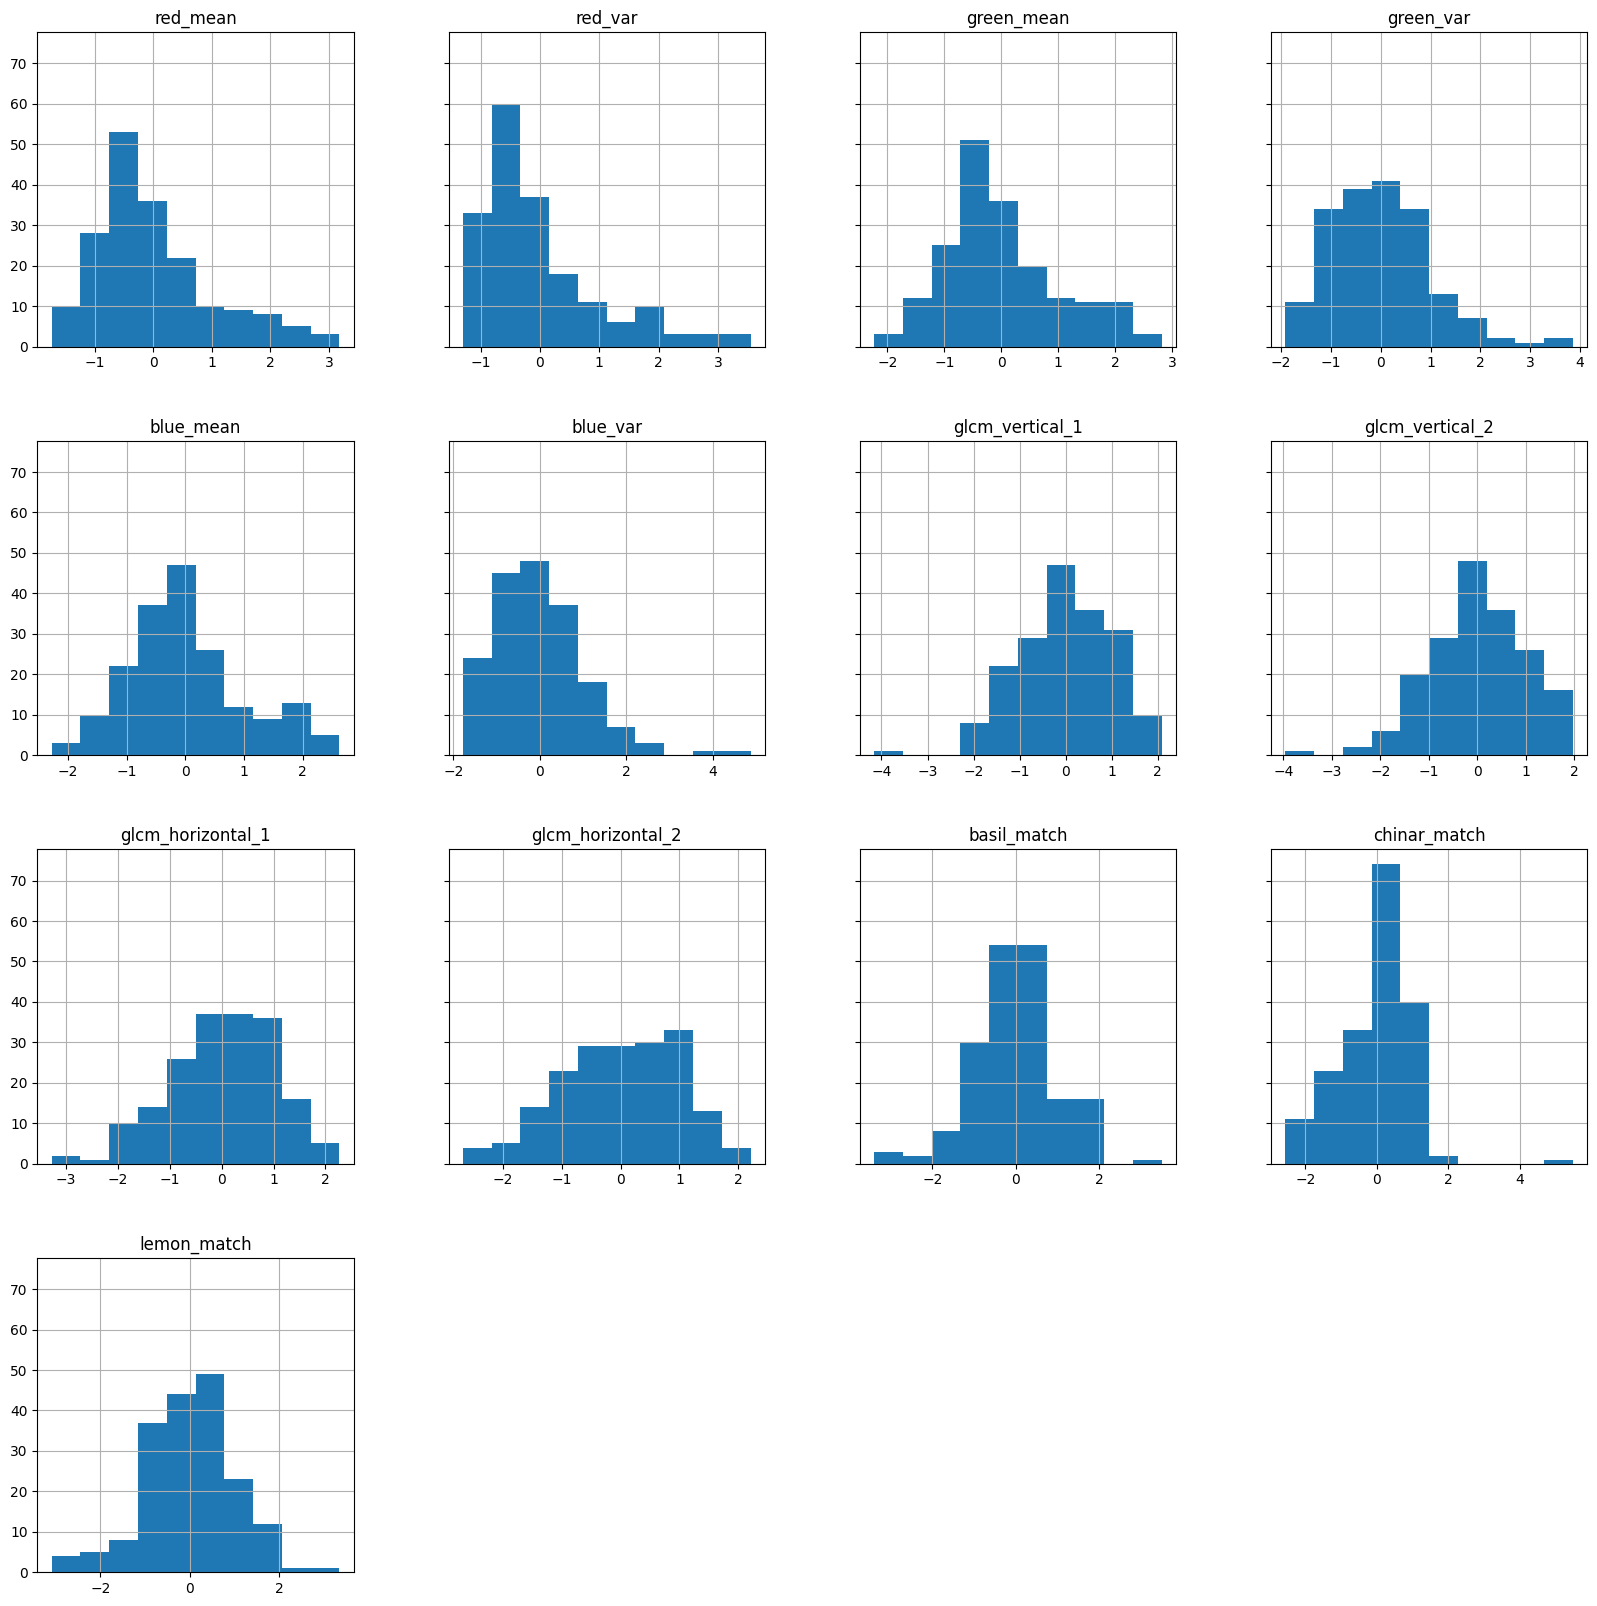

In [206]:
ax = X.hist(figsize=(20, 20), sharey=True)

<Axes: ylabel='Count'>

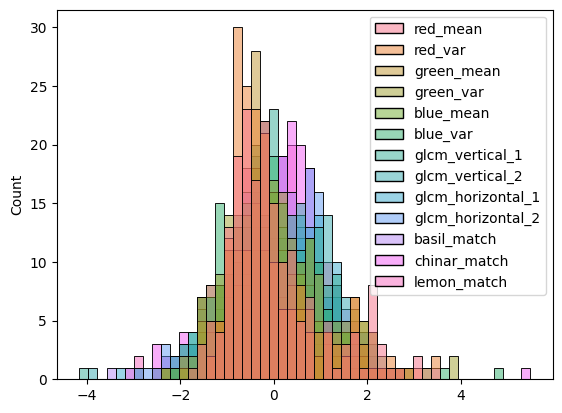

In [207]:
sns.histplot(X)

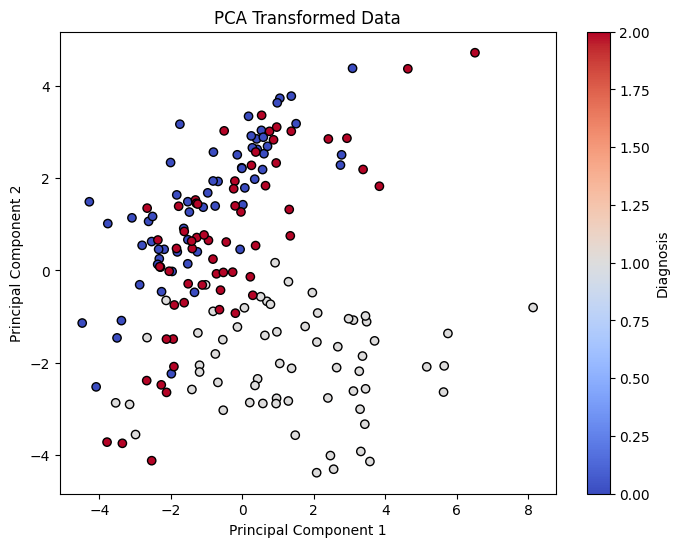

In [208]:
#PCA
pca = sk.decomposition.PCA(n_components=2)
X_pca = pca.fit_transform(X)

plt.figure(figsize=(8,6))
plt.scatter(X_pca[:, 0], X_pca[:, 1], c=y, cmap='coolwarm', edgecolor='k')
plt.xlabel("Principal Component 1")
plt.ylabel("Principal Component 2")
plt.title("PCA Transformed Data")
plt.colorbar(label="Diagnosis")
plt.show()


In [223]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42, stratify=y)

In [283]:
def nested_cross_validation(model, params):
    NUM_TRIALS = 1

    nested_scores = []

    # Loop for each trial
    for i in range(NUM_TRIALS):

        inner_cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=i)
        outer_cv = StratifiedKFold(n_splits=4, shuffle=True, random_state=i)

        # Nested CV with parameter optimization
        clf = GridSearchCV(estimator=model, param_grid=params, cv=inner_cv, n_jobs=-1, scoring='accuracy', return_train_score=True)
        clf.fit(X_train, y_train)
        
        nested_score = cross_val_score(clf, X=X_test, y=y_test, cv=outer_cv, n_jobs=-1)
        nested_scores.append((nested_score, clf))

    return nested_scores

In [284]:
ridge_params = {
  'alpha': [0.001, 0.01, 0.1, 1.0], 
  }
ridge_classifier = sklm.RidgeClassifier()
forest_params = {
    'n_estimators': range(100, 350, 50),
    'max_features': ['sqrt','log2',None],
    'bootstrap': [True],
}
forest_classifier = RandomForestClassifier()
mlp_params = {
  'hidden_layer_sizes': [(1,15),(1,20),(1,25),(1,30),(1,35),(1,40)],
  'activation': ['tanh', 'relu'],
  'solver': ['sgd', 'adam'],
  'validation_fraction': [0.1, 0.3],
  'alpha': [0.01, 0.1, 1],
  }
mlp_classifier = MLPClassifier() 

ridge = nested_cross_validation(ridge_classifier, ridge_params)
forest = nested_cross_validation(forest_classifier, forest_params)
mlp = nested_cross_validation(mlp_classifier, mlp_params)

/home/anton/venv/Data-Analysis/lib/python3.12/site-packages/sklearn/neural_network/_multilayer_perceptron.py:785: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (200) reached and the optimization hasn't converged yet.
  warnings.warn(
/home/anton/venv/Data-Analysis/lib/python3.12/site-packages/sklearn/neural_network/_multilayer_perceptron.py:785: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (200) reached and the optimization hasn't converged yet.
  warnings.warn(
/home/anton/venv/Data-Analysis/lib/python3.12/site-packages/sklearn/neural_network/_multilayer_perceptron.py:785: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (200) reached and the optimization hasn't converged yet.
  warnings.warn(
/home/anton/venv/Data-Analysis/lib/python3.12/site-packages/sklearn/neural_network/_multilayer_perceptron.py:785: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (200) reached and the optimization hasn't converged yet.
  warnings.warn(
/hom

In [285]:
def print_results(model, isForest):
  if(isForest):
    importances = forest[0][1].best_estimator_.feature_importances_
    feature_imp_df = pd.DataFrame({'Feature': X.columns, 'Gini Importance': importances}).sort_values(
    'Gini Importance', ascending=False)
    print(feature_imp_df)
  
  results_df = pd.DataFrame(model[0][1].cv_results_)
  results_df = results_df.sort_values(by=["rank_test_score"])
  results_df = results_df.set_index(
      results_df["params"].apply(lambda x: "_".join(str(val) for val in x.values()))
  ).rename_axis("kernel")
  print(results_df[["params", "rank_test_score", "mean_test_score", "std_test_score"]])

In [286]:
print("Ridge Classifier")
print_results(ridge, False)
print("Random Forest")
print_results(forest, True)
print("MLP")
print_results(mlp, False)

Ridge Classifier
                  params  rank_test_score  mean_test_score  std_test_score
kernel                                                                    
1.0       {'alpha': 1.0}                1         0.929538        0.063256
0.001   {'alpha': 0.001}                2         0.906154        0.072200
0.01     {'alpha': 0.01}                2         0.906154        0.072200
0.1       {'alpha': 0.1}                2         0.906154        0.072200
Random Forest
              Feature  Gini Importance
11       chinar_match         0.367131
0            red_mean         0.342749
9   glcm_horizontal_2         0.038762
7     glcm_vertical_2         0.033347
1             red_var         0.033016
12        lemon_match         0.031271
10        basil_match         0.030910
4           blue_mean         0.028981
6     glcm_vertical_1         0.024468
8   glcm_horizontal_1         0.023372
2          green_mean         0.019776
5            blue_var         0.018909
3           

In [314]:
ridge_y = ridge[0][1].predict(X)
forest_y = forest[0][1].predict(X)
mlp_y = mlp[0][1].predict(X)

labels = ['Basil', 'Chinar', 'Lemon']
cm_ridge = confusion_matrix(y, ridge_y)
cm_forest = confusion_matrix(y, forest_y)
cm_mlp = confusion_matrix(y, mlp_y)

In [318]:
def conf_matrix(cm, labels, title):
  disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=labels)
  disp.plot(cmap=plt.cm.Blues)
  plt.title(title, fontsize=15, pad=20)
  plt.xlabel('Prediction', fontsize=11)
  plt.ylabel('Actual', fontsize=11)
  plt.gca().xaxis.set_label_position('top')
  plt.gca().xaxis.tick_top()
  plt.gca().figure.subplots_adjust(bottom=0.2)
  plt.gca().figure.text(0.5, 0.05, 'Prediction', ha='center', fontsize=13)

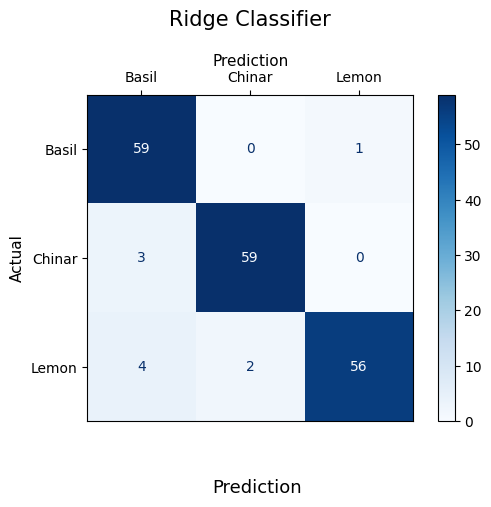

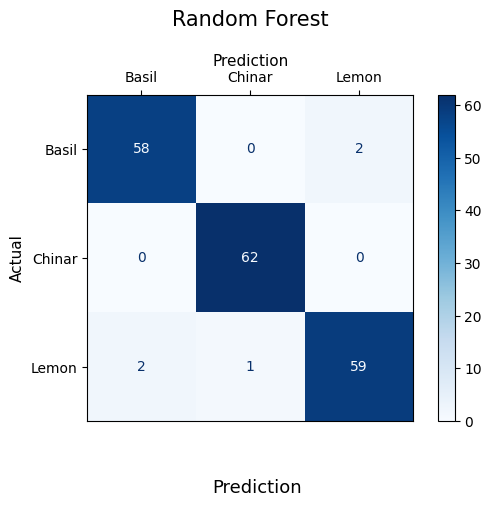

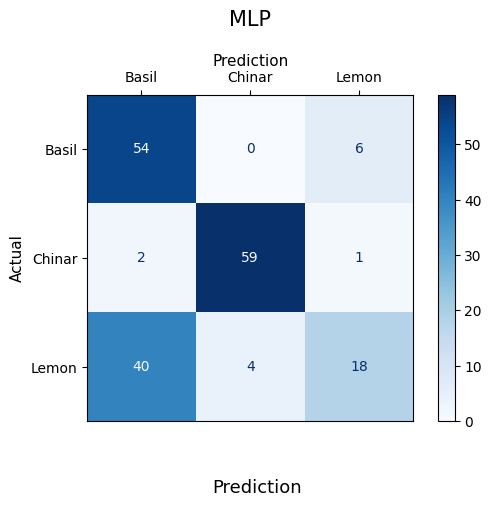

In [320]:
conf_matrix(cm_ridge, labels, 'Ridge Classifier')
conf_matrix(cm_forest, labels, 'Random Forest')
conf_matrix(cm_mlp, labels, 'MLP')

In [321]:
print(classification_report(y, ridge_y, target_names=labels))
print(classification_report(y, forest_y, target_names=labels))
print(classification_report(y, mlp_y, target_names=labels))

              precision    recall  f1-score   support

       Basil       0.89      0.98      0.94        60
      Chinar       0.97      0.95      0.96        62
       Lemon       0.98      0.90      0.94        62

    accuracy                           0.95       184
   macro avg       0.95      0.95      0.95       184
weighted avg       0.95      0.95      0.95       184

              precision    recall  f1-score   support

       Basil       0.97      0.97      0.97        60
      Chinar       0.98      1.00      0.99        62
       Lemon       0.97      0.95      0.96        62

    accuracy                           0.97       184
   macro avg       0.97      0.97      0.97       184
weighted avg       0.97      0.97      0.97       184

              precision    recall  f1-score   support

       Basil       0.56      0.90      0.69        60
      Chinar       0.94      0.95      0.94        62
       Lemon       0.72      0.29      0.41        62

    accuracy        

In [323]:
print(ridge[0][1].cv_results_['mean_test_score'].mean())
print(forest[0][1].cv_results_['mean_test_score'].mean())
print(mlp[0][1].cv_results_['mean_test_score'].mean())

0.9119999999999999
0.8956512820512821
0.5676495726495726
